# 🌾 CropNexus — Notebook 4: Final Model, Evaluation, Save & Conclusion

This notebook picks the winning model, checks it carefully, and saves it. We do this last step so the Flask app has a ready-to-use, well-tested model file to load.

## Import Libraries & Load Artifacts from Notebook 3
We reload the tuned models from Notebook 3 so we can pick and finalize the best one without retraining everything again.

In [1]:
import pandas as pd
import numpy as np
import joblib, json, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid", palette="Set2")

train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")
FEATURES = [c for c in train_df.columns if c != "label"]

le = LabelEncoder()
le.fit(pd.concat([train_df["label"], test_df["label"]]))
X_train, y_train = train_df[FEATURES], le.transform(train_df["label"])
X_test, y_test = test_df[FEATURES], le.transform(test_df["label"])

scaler = StandardScaler().fit(X_train)
X_test_s = scaler.transform(X_test)

tuned_models = joblib.load("../data/processed/_tuned_models.joblib")
tuned_df = joblib.load("../data/processed/_tuned_results.joblib")
tuned_df

,Model,Test Accuracy,F1 Score
0,Random Forest (Tuned),0.9932,0.9932
1,XGBoost (Tuned),0.9886,0.9886


## 14. Final Model
We pick the model with the highest test accuracy because that's our best evidence of how it will perform on new, real farmer data.

In [2]:
best_name = tuned_df.iloc[0]["Model"]
best_model, best_needs_scaling, best_params = tuned_models[best_name]

print("Final model selected:", best_name)
print("Best hyperparameters:", best_params)

Final model selected: Random Forest (Tuned)
Best hyperparameters: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 250}


## 15. Model Evaluation
We look at the classification report and confusion matrix because overall accuracy alone can hide mistakes on specific crops; this shows exactly where the model is strong or weak.

In [3]:
X_eval = X_test_s if best_needs_scaling else X_test
final_preds = best_model.predict(X_eval)

final_acc = accuracy_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds, average="weighted")
print(f"Final Test Accuracy: {final_acc:.4f}")
print(f"Final Weighted F1:  {final_f1:.4f}\n")
print(classification_report(y_test, final_preds, target_names=le.classes_))

Final Test Accuracy: 0.9932
Final Weighted F1:  0.9932

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00  

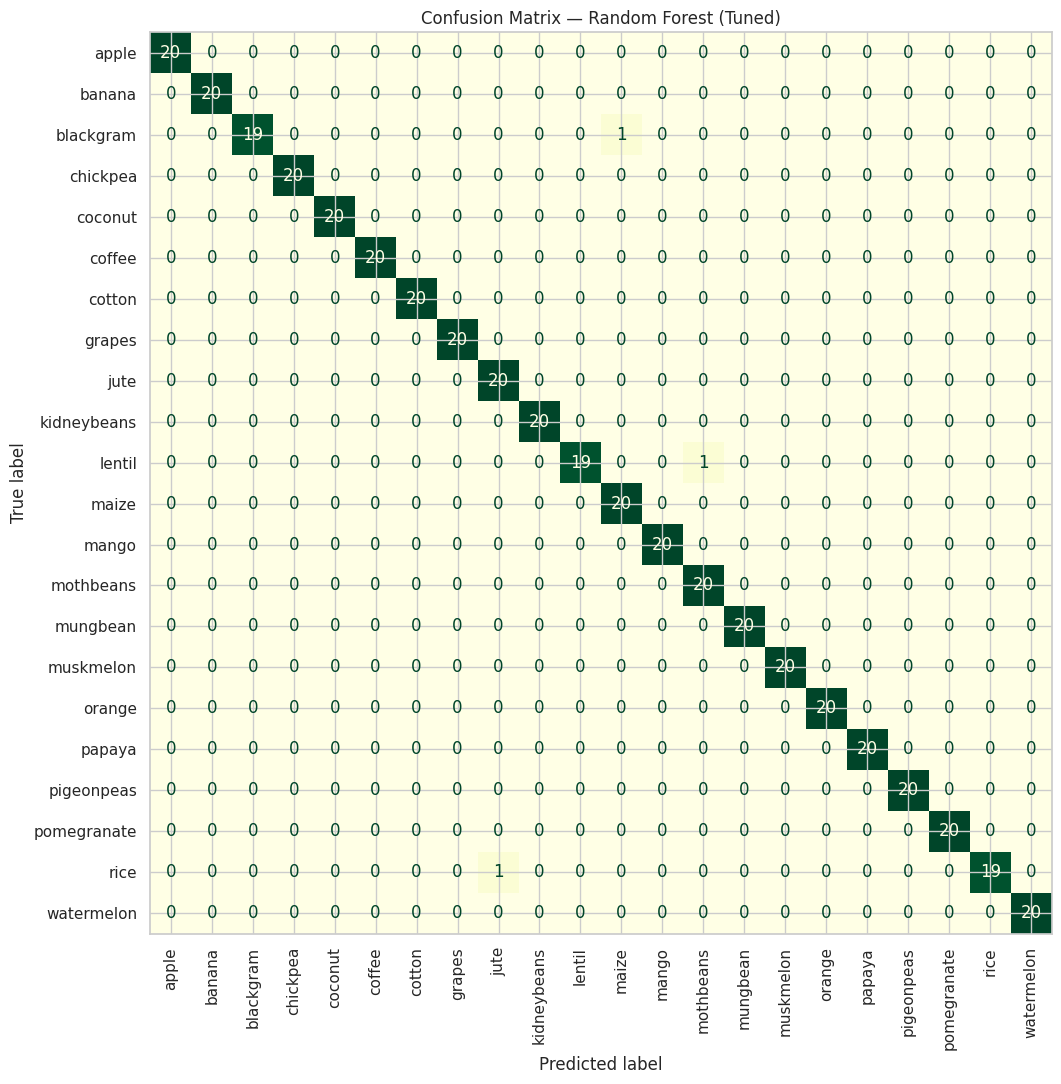

In [4]:
cm = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(12, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="YlGn", xticks_rotation=90, colorbar=False)
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("../data/processed/final_confusion_matrix.png", dpi=110)
plt.show()

/tmp/ipykernel_664/3297097636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="YlGn_r")


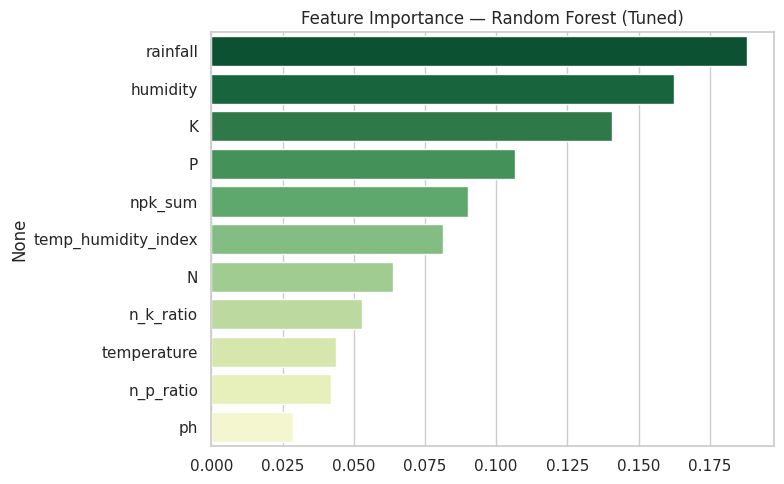

rainfall               0.188173
humidity               0.162377
K                      0.140705
P                      0.106508
npk_sum                0.090125
temp_humidity_index    0.081463
N                      0.063646
n_k_ratio              0.052736
temperature            0.043806
n_p_ratio              0.041917
ph                     0.028546
dtype: float64

In [5]:
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=imp.values, y=imp.index, palette="YlGn_r")
    plt.title(f"Feature Importance — {best_name}")
    plt.tight_layout()
    plt.savefig("../data/processed/final_feature_importance.png", dpi=110)
    plt.show()
    display(imp)

## 16. Save Model (.joblib)
We save the model, scaler, and label encoder as files because the Flask app needs these exact files to make predictions later without retraining.

In [6]:
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model, f"{MODEL_DIR}/cropnexus_model.joblib")
joblib.dump(scaler, f"{MODEL_DIR}/scaler.joblib")
joblib.dump(le, f"{MODEL_DIR}/label_encoder.joblib")
joblib.dump(FEATURES, f"{MODEL_DIR}/feature_names.joblib")

metrics = {
    "final_model_name": best_name,
    "uses_scaling": best_needs_scaling,
    "best_params": best_params,
    "test_accuracy": round(float(final_acc), 4),
    "weighted_f1": round(float(final_f1), 4),
    "n_classes": len(le.classes_),
    "classes": le.classes_.tolist(),
}
with open(f"{MODEL_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved: cropnexus_model.joblib, scaler.joblib, label_encoder.joblib, feature_names.joblib, metrics.json")

Saved: cropnexus_model.joblib, scaler.joblib, label_encoder.joblib, feature_names.joblib, metrics.json


In [7]:
# Quick sanity check: reload from disk and predict on one sample, exactly like the Flask app does
loaded_model = joblib.load(f"{MODEL_DIR}/cropnexus_model.joblib")
loaded_scaler = joblib.load(f"{MODEL_DIR}/scaler.joblib")
loaded_le = joblib.load(f"{MODEL_DIR}/label_encoder.joblib")

sample = pd.DataFrame([X_test.iloc[0]], columns=FEATURES)
sample_in = loaded_scaler.transform(sample) if best_needs_scaling else sample
pred_label = loaded_le.inverse_transform(loaded_model.predict(sample_in))[0]
true_label = loaded_le.inverse_transform([y_test[0]])[0]
print("Predicted:", pred_label, "| Actual:", true_label)

Predicted: orange | Actual: orange
